# 10. Scaling and Feature Engineering for Regression
@Shengli (Bruce) Jiang, University of South Carolina

Can we improve battery lifetime predictions by changing how we represent the measurements?

Use the same `data/battery/` folder as Lecture 09. Run the notebook from top to bottom.

## What We Have Covered

- Python, NumPy, pandas, functions, and plotting
- Linear and nonlinear regression
- Training and test errors, RMSE, MAE, and R-squared
- Ridge, Lasso, Elastic Net, and model selection
- Cross-validation and pipelines

## What We Covered in the Last Lecture

We used six measurements from early battery cycles to predict lifetime. We selected
regularization strength using a validation set, then repeated the calculation with
five-fold cross-validation. A pipeline kept scaling inside the training step.
We also compared predictions from raw and log-transformed targets.

## Today's Learning Objectives

By the end of this notebook, you should be able to:

1. Explain how scaling and nonlinear transformations change a regression problem.
2. Construct interaction terms, polynomial terms, and physical ratios.
3. Compare representations using the same data split and selection rule.
4. Evaluate predictions in cycles, including models trained on transformed targets.

## 1. Training, validation, and test

A single validation group can be unusually easy or difficult. K-fold cross-validation
repeats training and validation across several groups. A fold is one group of observations.
Five-fold CV uses four groups for training and the remaining group for validation, then
rotates that role and averages the five scores.

The main experiment below uses **one fixed split**, not five-fold CV:

| Role | Batteries | Use |
| :-- | --: | :-- |
| Training | 41 | Learn transformations and regression coefficients |
| Validation | 43 | Select the representation and hyperparameters |
| Development | 84 | Retrain each selected pipeline before test evaluation |
| Test | 40 | Evaluate the selected pipelines |

We use that fixed split for the main experiment. A separate exercise repeats a limited
comparison with five-fold CV. Its scores have different validation samples and stay in
separate variables and figures.

These test batteries have already appeared in class. This is a reproduction of the
classroom experiment, not a new independent test of the method. All comparisons below
are specified before the test results are calculated.

In [1]:
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import ElasticNet, LassoLars, Ridge
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, ParameterGrid, PredefinedSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer, MaxAbsScaler, MinMaxScaler, PolynomialFeatures,
    PowerTransformer, RobustScaler, StandardScaler,
)

DATA_DIR = next((p for p in [Path("data/battery"), Path("notebook/data/battery")]
                 if (p / "features.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Keep the data/battery folder beside this notebook.")

# Use pandas only to read the CSV. The calculations below use NumPy arrays.
data = pd.read_csv(DATA_DIR / "features.csv")
FEATURES = [
    "log10_var_dQ100_10", "log10_abs_min_dQ100_10", "mean_dQ100_10_Ah",
    "max_Qdlin_cycle2_Ah", "max_Qdlin_cycle100_minus2_Ah",
    "max_Qdlin_slope_cycles2_100_Ah_per_cycle",
]
X = data[FEATURES].to_numpy(dtype=float)
y = data["cycle_life"].to_numpy(dtype=float)
split = data["split"].to_numpy()
cell_ids = data["cell_id"].to_numpy()

# The file already assigns every battery to one of three groups.
train_mask = split == "train"
val_mask = split == "primary_test"
test_mask = split == "secondary_test"
X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

# Development data contain the rows available before the final test.
X_dev = np.vstack([X_train, X_val])
y_dev = np.concatenate([y_train, y_val])

assert (len(y_train), len(y_val), test_mask.sum()) == (41, 43, 40)
assert len(np.unique(cell_ids)) == len(cell_ids)
assert np.isfinite(X).all() and np.isfinite(y).all() and np.all(y > 0)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
print("scikit-learn:", sklearn.__version__)
print("Training:", len(y_train), "Validation:", len(y_val), "Test:", test_mask.sum())

scikit-learn: 1.9.0
Training: 41 Validation: 43 Test: 40


`PredefinedSplit` gives `GridSearchCV` our existing training and validation groups.
The value `-1` means always use this row for training. The value `0` identifies the
single validation group. `GridSearchCV` does not require k-fold CV.
After selection, `refit=True` retrains the selected pipeline on all 84 development batteries.

In [2]:
# -1 keeps a row in training. 0 assigns a row to the validation group.
validation_group = np.r_[np.full(len(y_train), -1), np.zeros(len(y_val), dtype=int)]
fixed_split = PredefinedSplit(validation_group)
training_index, validation_index = next(fixed_split.split())
print("Number of validation splits:", fixed_split.get_n_splits())
print("Training:", len(training_index), "Validation:", len(validation_index))

Number of validation splits: 1
Training: 41 Validation: 43


## 2. The same regression problem

Each row describes one battery. The target is total lifetime in cycles at the released
80%-capacity threshold. It is not the remaining lifetime after cycle 100.

| Column | Measurement |
| :-- | :-- |
| 0 | Log10 variance of the capacity-difference curve between cycles 100 and 10 |
| 1 | Log10 magnitude of the minimum of that difference curve |
| 2 | Mean of that difference curve, Ah |
| 3 | Maximum curve capacity at cycle 2, Ah |
| 4 | Change in maximum curve capacity from cycle 2 to cycle 100, Ah |
| 5 | Linear trend in maximum curve capacity over cycles 2-100, Ah/cycle |

The first two columns already contain logarithms. The six columns do not include cell
IDs, split labels, or lifetime. The data definitions are the same as in Lecture 09.

### The starting models

We start with standard-scaled inputs and an untransformed target. Each model chooses
alpha using the same 43 validation batteries. Errors always use the original cycle units.

`LassoLars` solves the Lasso objective with a different algorithm from `Lasso`.
We use it for the Lasso calculations below and keep one alpha grid for each target scale.
Ridge and Lasso use different alpha grids because their penalties have different scales.

In [3]:
ridge_alphas = np.logspace(-6, 6, 13)
lasso_raw_alphas = np.unique(np.r_[np.logspace(-1, 4, 21), 10.0 ** 1.3])
lasso_log_alphas = np.unique(np.r_[np.logspace(-3, 1, 17), 10.0 ** -2.2])
model_choices = {"Ridge": Ridge(solver="svd"), "Lasso": LassoLars(max_iter=5000)}
baseline_searches = {}

for name, regressor in model_choices.items():
    # Scaling stays inside the pipeline, so it learns from training rows only.
    pipeline = Pipeline([("scale", StandardScaler()), ("model", clone(regressor))])
    alphas = ridge_alphas if name == "Ridge" else lasso_raw_alphas
    # The validation score selects alpha. refit=True then trains on all 84 rows.
    baseline_searches[name] = GridSearchCV(
        pipeline, {"model__alpha": alphas}, cv=fixed_split,
        scoring="neg_root_mean_squared_error", return_train_score=True,
        refit=True, error_score="raise",
    ).fit(X_dev, y_dev)
    search = baseline_searches[name]
    print(f"{name}: alpha = {search.best_params_['model__alpha']:.3g}, "
          f"validation RMSE = {-search.best_score_:.2f} cycles")

Ridge: alpha = 1e-06, validation RMSE = 153.06 cycles
Lasso: alpha = 20, validation RMSE = 148.90 cycles


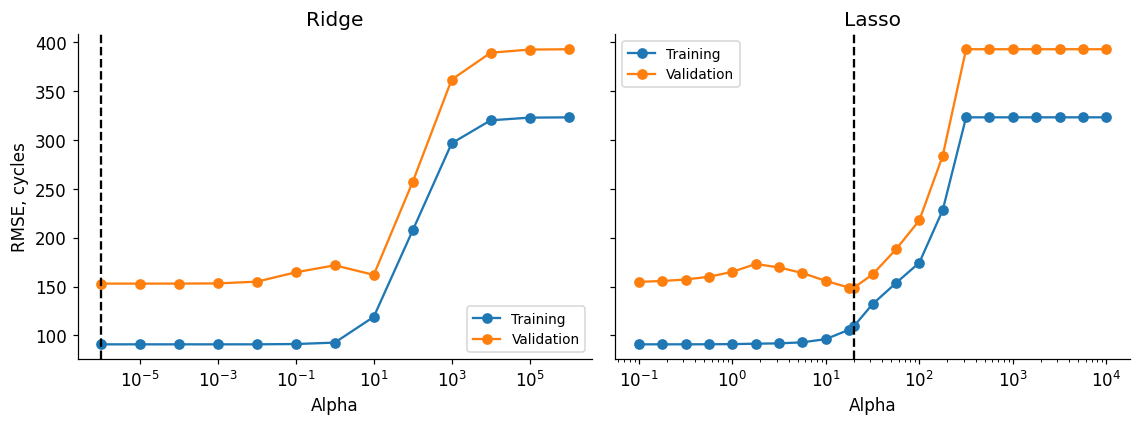

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), sharey=True)
for ax, (name, search) in zip(axes, baseline_searches.items()):
    alphas = np.asarray(search.cv_results_["param_model__alpha"], dtype=float)
    ax.semilogx(alphas, -search.cv_results_["mean_train_score"], "o-", label="Training")
    ax.semilogx(alphas, -search.cv_results_["mean_test_score"], "o-", label="Validation")
    ax.axvline(search.best_params_["model__alpha"], color="black", linestyle="--")
    ax.set(xlabel="Alpha", title=name)
    ax.legend(fontsize=9)
axes[0].set_ylabel("RMSE, cycles")
fig.tight_layout()
plt.show()

The five-fold validation RMSE of 125.92 from Lecture 09 belongs to a different selection
procedure. The fixed-split Lasso baseline here is about 148.90 cycles. We calculate every
reference line from the matching experiment instead of mixing those two scores.

## 3. Scaling and nonlinear transformations

Scaling changes the units and spacing seen by the model. This changes the meaning of
a coefficient penalty, so we retune alpha after changing the input representation.
Nonlinear transformations can also change the relationship between an input and the target.

The next six figures use only the **41 training batteries**. Each shows the first input
against lifetime, with a histogram above and to the right. We transform the input and target
separately. These are feature-target scatter plots, not prediction parity plots.

In [5]:
x_label = r"$\log_{10}[\mathrm{Var}(\Delta Q_{100-10}(V))]$"


def joint_panel(fig, slot, x, y, title, xlabel, ylabel):
    # Main scatter plot with one marginal histogram for each variable.
    grid = slot.subgridspec(2, 2, height_ratios=(1, 4), width_ratios=(4, 1),
                           hspace=0.05, wspace=0.05)
    ax_top = fig.add_subplot(grid[0, 0])
    ax = fig.add_subplot(grid[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(grid[1, 1], sharey=ax)
    ax.scatter(x, y, s=35, alpha=0.7, edgecolor="black", linewidth=0.4)
    ax_top.hist(x, bins=10, color="C0", alpha=0.65, edgecolor="black", linewidth=0.7)
    ax_right.hist(y, bins=10, orientation="horizontal", color="C0", alpha=0.65,
                  edgecolor="black", linewidth=0.7)
    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax_top.set_title(title)
    ax_top.tick_params(axis="x", labelbottom=False)
    ax_right.tick_params(axis="y", labelleft=False)
    ax_top.set_yticks([])
    ax_right.set_xticks([])
    for marginal in (ax_top, ax_right):
        for spine in marginal.spines.values():
            spine.set_visible(False)
    return ax


def show_transformation(transformer, name):
    # Fit each transformer on the 41 training batteries shown in the figure.
    x, y = X_train[:, 0], y_train
    x_transformed = clone(transformer).fit_transform(x[:, None]).ravel()
    y_transformed = clone(transformer).fit_transform(y[:, None]).ravel()
    fig = plt.figure(figsize=(11, 4.6), layout="constrained")
    slots = fig.add_gridspec(1, 2, wspace=0.15)
    joint_panel(fig, slots[0], x, y, "Stored units", x_label, "Cycle life, cycles")
    ax = joint_panel(fig, slots[1], x_transformed, y_transformed, name,
                     "Transformed first feature", "Transformed cycle life")
    if isinstance(transformer, (StandardScaler, RobustScaler, PowerTransformer)):
        ax.axvline(0, color="black", linestyle=":", linewidth=1)
        ax.axhline(0, color="black", linestyle=":", linewidth=1)
    plt.show()

### StandardScaler

Subtract the training mean and divide by the training standard deviation.
For a nonconstant variable, the transformed training mean is 0 and standard deviation is 1.
The histogram shape and Pearson correlation stay the same. Extreme values influence both statistics.

```latex
x_{\mathrm{scaled}}=\frac{x-\mu_{\mathrm{train}}}{s_{\mathrm{train}}}
```

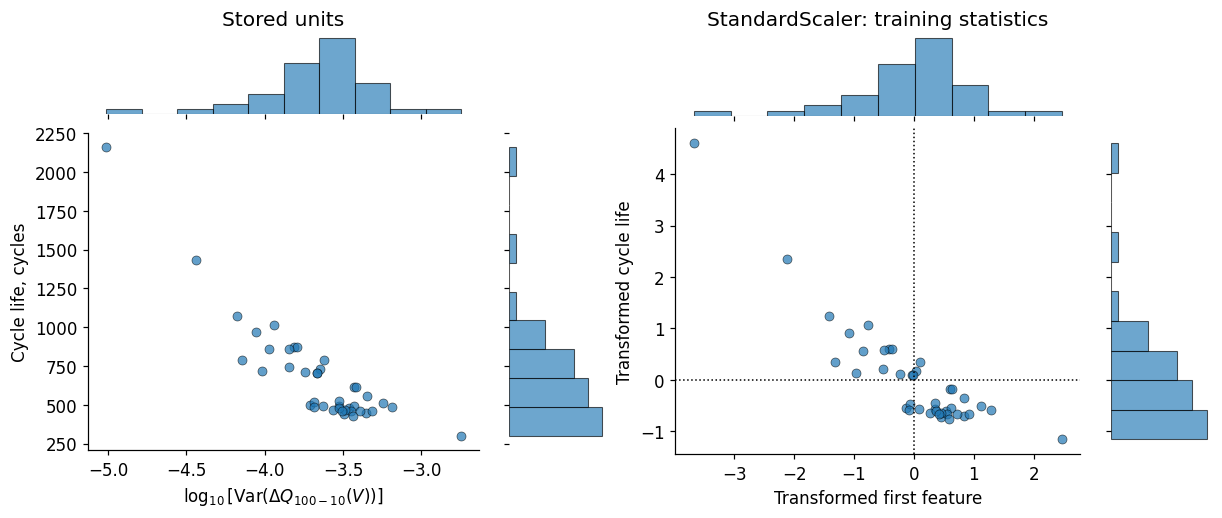

In [6]:
show_transformation(StandardScaler(), "StandardScaler: training statistics")

### MinMaxScaler

Subtract the training minimum and divide by the training range. For a nonconstant variable,
the training minimum becomes 0 and maximum becomes 1. New values can fall outside this range.
A distant extreme can compress the other values into a small interval.

```latex
x_{\mathrm{scaled}}=\frac{x-x_{\min,\mathrm{train}}}{x_{\max,\mathrm{train}}-x_{\min,\mathrm{train}}}
```

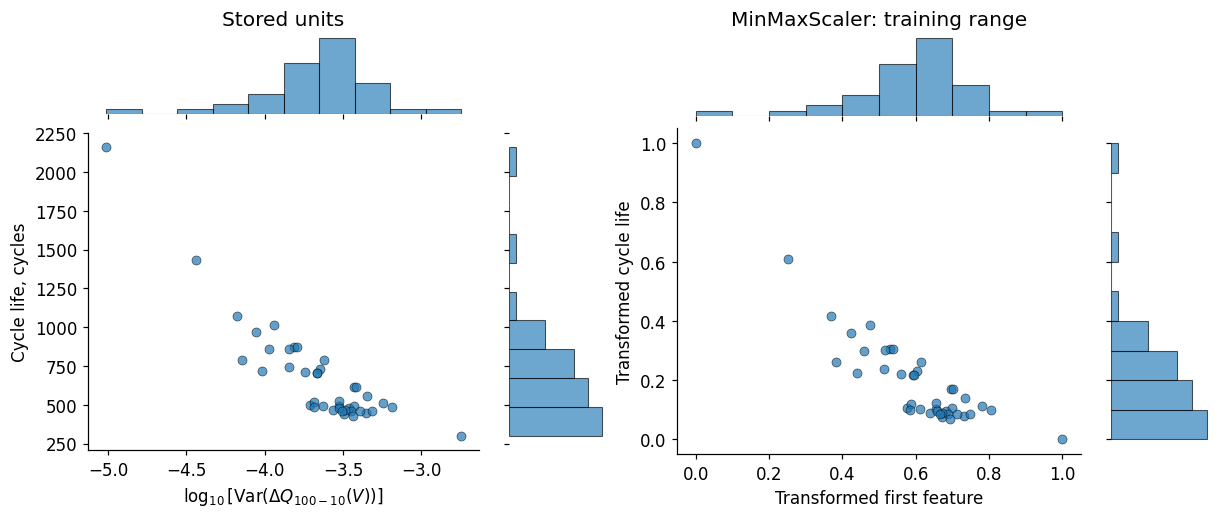

In [7]:
show_transformation(MinMaxScaler(), "MinMaxScaler: training range")

### MaxAbsScaler

Divide by the largest training absolute value. For a variable with nonzero values,
the largest training magnitude becomes 1. Zero and signs stay the same.
The result does not have to reach both -1 and 1. Extreme values still determine the scale.

```latex
x_{\mathrm{scaled}}=\frac{x}{\max_{i\in\mathrm{train}}|x_i|}
```

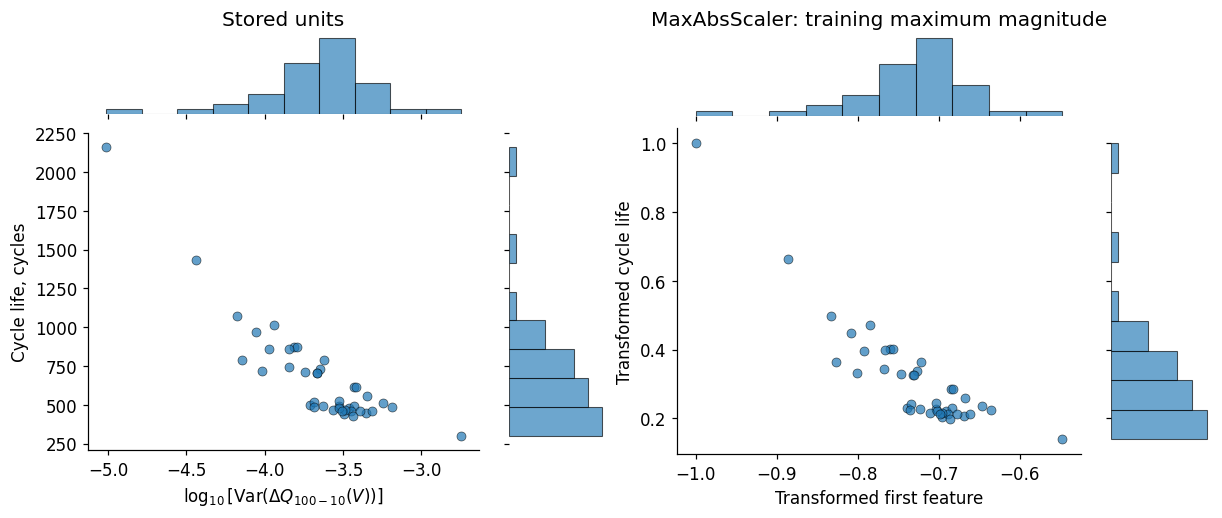

In [8]:
show_transformation(MaxAbsScaler(), "MaxAbsScaler: training maximum magnitude")

### RobustScaler

Subtract the training median and divide by the interquartile range, or IQR.
With a nonzero IQR, the transformed training median is 0 and IQR is 1.
Outliers have less influence on these scaling statistics, but the transformation does not remove them.

```latex
x_{\mathrm{scaled}}=\frac{x-\mathrm{median}(x_{\mathrm{train}})}{Q_{0.75}(x_{\mathrm{train}})-Q_{0.25}(x_{\mathrm{train}})}
```

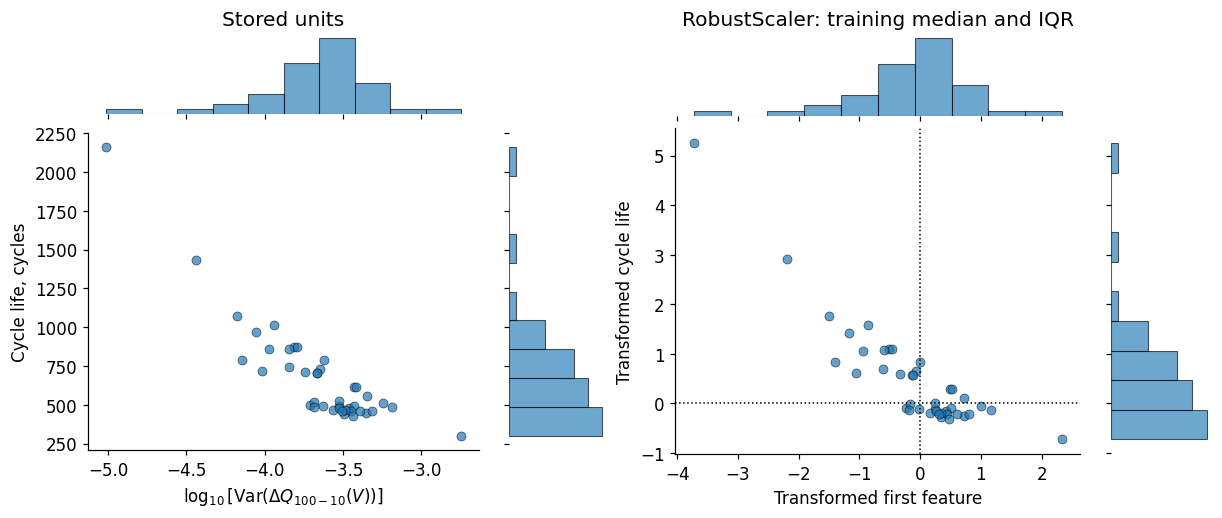

In [9]:
show_transformation(RobustScaler(), "RobustScaler: training median and IQR")

### Yeo-Johnson transformation

A power transformation changes the spacing between values. Yeo-Johnson supports positive,
zero, and negative values. It estimates a power parameter from each training column using
maximum likelihood. It can reduce skewness, but it does not guarantee a normal distribution.

`PowerTransformer(method="yeo-johnson", standardize=True)` applies the power transformation
and then standardizes the result. Order stays the same, while distances and Pearson
correlation can change.

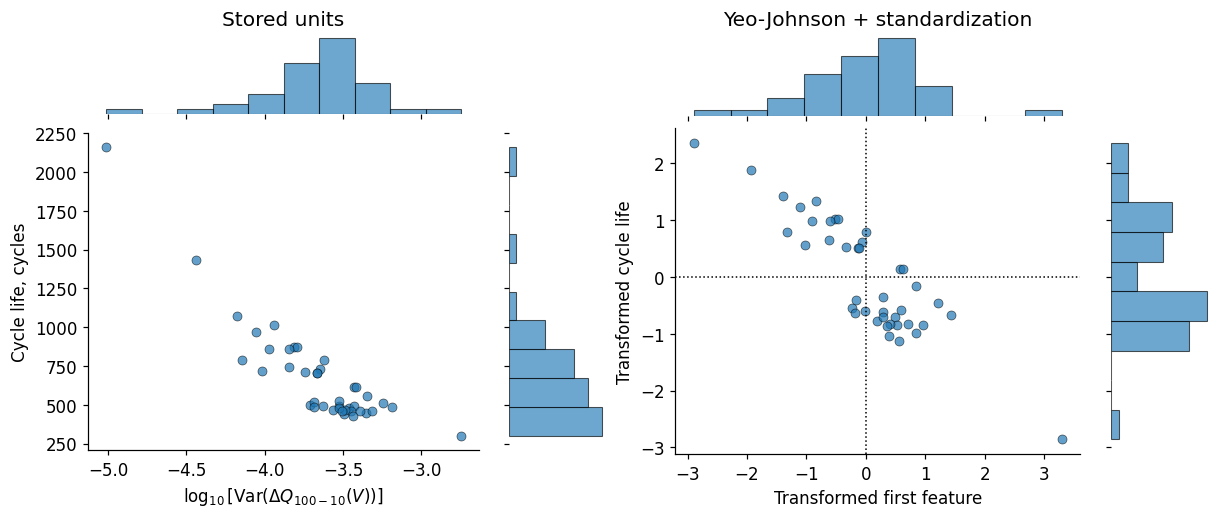

In [10]:
show_transformation(PowerTransformer(method="yeo-johnson"), "Yeo-Johnson + standardization")

### Log transformation

A logarithm compresses large positive values more strongly than small ones. It can make
a long right tail less pronounced. It requires positive input values.

The first stored feature is already log10 variance. For this illustration only, we recover
the positive variance before taking its logarithm. The regression experiments continue to
use the same six stored columns.

```latex
x_{\mathrm{log}}=\log_{10}(x),\qquad x>0
```

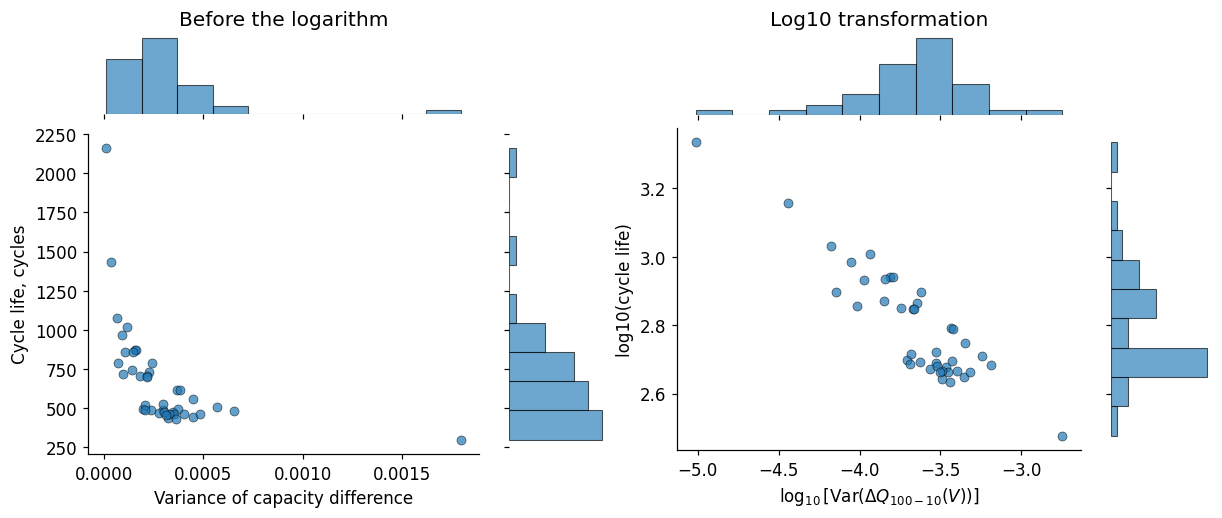

In [11]:
variance = 10.0 ** X_train[:, 0]
fig = plt.figure(figsize=(11, 4.6), layout="constrained")
slots = fig.add_gridspec(1, 2, wspace=0.15)
joint_panel(fig, slots[0], variance, y_train, "Before the logarithm",
            "Variance of capacity difference", "Cycle life, cycles")
joint_panel(fig, slots[1], np.log10(variance), np.log10(y_train), "Log10 transformation",
            x_label, "log10(cycle life)")
plt.show()

### Which method would you try?

| Situation | A possible starting point |
| :-- | :-- |
| Different feature units, no strong outliers | StandardScaler |
| A specified training range of 0 to 1 | MinMaxScaler |
| Sparse inputs with meaningful zeros | MaxAbsScaler |
| A few extreme observations | RobustScaler |
| A positive variable with a long right tail | Log |
| A skewed variable with negative or zero values | Yeo-Johnson |

These are reasons to try a method, not guarantees that it will predict better.
A log transformation followed by StandardScaler is a valid combination. The first
changes shape and spacing; the second changes location and scale.

**Discuss:** Would standardization alone straighten the curved relationship in the scatter plot?
Why should a model trained on log lifetime return predictions to cycles before we calculate RMSE?

## 4. Comparing input and target preprocessing

We first keep the same six stored features and the same Lasso model. We change only:

- input preprocessing: `StandardScaler`, `MinMaxScaler`, or Yeo-Johnson;
- target preprocessing: raw cycle life or log10 cycle life;
- alpha, which is retuned for every combination.

This focused comparison contains six separate searches. The test set is not used here.
`TransformedTargetRegressor` automatically returns predictions to cycles before RMSE is calculated.

In [12]:
def pow10(values):
    return np.power(10.0, values)


input_preprocessors = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "Yeo-Johnson": PowerTransformer(method="yeo-johnson", standardize=True),
}
target_preprocessors = {
    "Raw": FunctionTransformer(),
    "Log10": FunctionTransformer(np.log10, inverse_func=pow10),
}


def tune_regression(feature_step, input_step, target_step, model, alphas, cv):
    # Build one pipeline and select alpha using the supplied validation splits.
    pipeline = Pipeline([
        ("features", feature_step),
        ("preprocess", input_step),
        ("model", model),
    ])
    estimator = TransformedTargetRegressor(
        regressor=pipeline,
        transformer=target_step,
    )
    search = GridSearchCV(
        estimator,
        {"regressor__model__alpha": alphas},
        scoring="neg_root_mean_squared_error",
        cv=cv,
        refit=True,
        error_score="raise",
    )
    return search.fit(X_dev, y_dev)

In [13]:
# Run the six focused Lasso searches.
scaling_searches = {}
for target_name, target_step in target_preprocessors.items():
    alphas = lasso_raw_alphas if target_name == "Raw" else lasso_log_alphas
    for input_name, input_step in input_preprocessors.items():
        search = tune_regression(
            "passthrough", input_step, target_step,
            LassoLars(max_iter=5000), alphas, fixed_split,
        )
        scaling_searches[(input_name, target_name)] = search

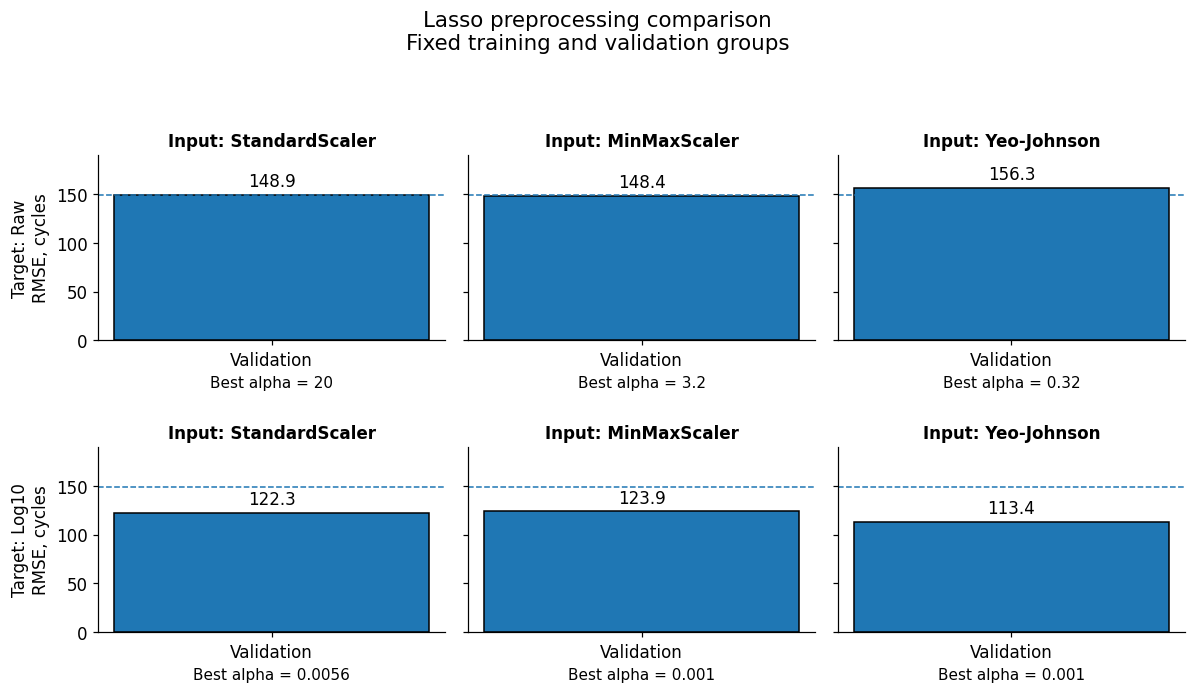

In [14]:
# Plot validation RMSE only. Test results appear after all choices are specified.
fig, axes = plt.subplots(2, 3, figsize=(11, 6.4), sharey=True)
for row, target_name in enumerate(target_preprocessors):
    for column, input_name in enumerate(input_preprocessors):
        ax = axes[row, column]
        search = scaling_searches[(input_name, target_name)]
        validation_rmse = -search.best_score_
        alpha = search.best_params_["regressor__model__alpha"]
        bars = ax.bar(["Validation"], [validation_rmse], width=0.5,
                      color="C0", edgecolor="black")
        ax.bar_label(bars, fmt="%.1f", padding=3)
        ax.axhline(-baseline_searches["Lasso"].best_score_,
                   color="C0", linestyle="--", linewidth=1)
        ax.set_title(f"Input: {input_name}", fontsize=11, fontweight="bold")
        ax.set_xlabel(f"Best alpha = {alpha:.2g}", fontsize=10)
        if column == 0:
            ax.set_ylabel(f"Target: {target_name}\nRMSE, cycles")
        ax.set_ylim(0, 190)

fig.suptitle("Lasso preprocessing comparison\nFixed training and validation groups", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.92], h_pad=2)
plt.show()

**Discuss:** Which preprocessing combination has the lowest validation RMSE?
Why can Yeo-Johnson help with a log10 target but hurt with a raw target?

The dashed line is the `StandardScaler` and raw-target Lasso baseline from Section 2.

## 5. Feature engineering

The next examples add columns using the existing measurements. The number of batteries
stays the same. We consider interaction features, polynomial features, and physical ratios.

### Interaction features

A product allows the effect of one input to depend on another. For two inputs:

```latex
\hat{y}=\theta_0+\theta_1x_1+\theta_2x_2+\theta_{12}x_1x_2
```

`interaction_only=True` adds products of different inputs and omits their squares.
`include_bias=False` omits a constant column because the regression already learns an intercept.

In [15]:
example = np.array([[2.0, 3.0]])
interaction_features = PolynomialFeatures(2, interaction_only=True, include_bias=False)
expanded = interaction_features.fit_transform(example)
print("Columns:", interaction_features.get_feature_names_out(["x1", "x2"]))
print("Values:", expanded[0])
print("Six inputs produce", interaction_features.fit_transform(X_train).shape[1], "columns")

Columns: ['x1' 'x2' 'x1 x2']
Values: [2. 3. 6.]
Six inputs produce 21 columns


### Polynomial features

The full degree-2 expansion also includes squares, which allow curvature.
The model remains linear in its learned coefficients even when its prediction is nonlinear in the inputs.

```latex
\hat{y}=\theta_0+\theta_1x_1+\theta_2x_2+\theta_{11}x_1^2+\theta_{12}x_1x_2+\theta_{22}x_2^2
```

In [16]:
polynomial_features = PolynomialFeatures(2, include_bias=False)
expanded = polynomial_features.fit_transform(example)
print("Columns:", polynomial_features.get_feature_names_out(["x1", "x2"]))
print("Values:", expanded[0])
print("Six inputs produce", polynomial_features.fit_transform(X_train).shape[1], "columns")

Columns: ['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']
Values: [2. 3. 4. 6. 9.]
Six inputs produce 27 columns


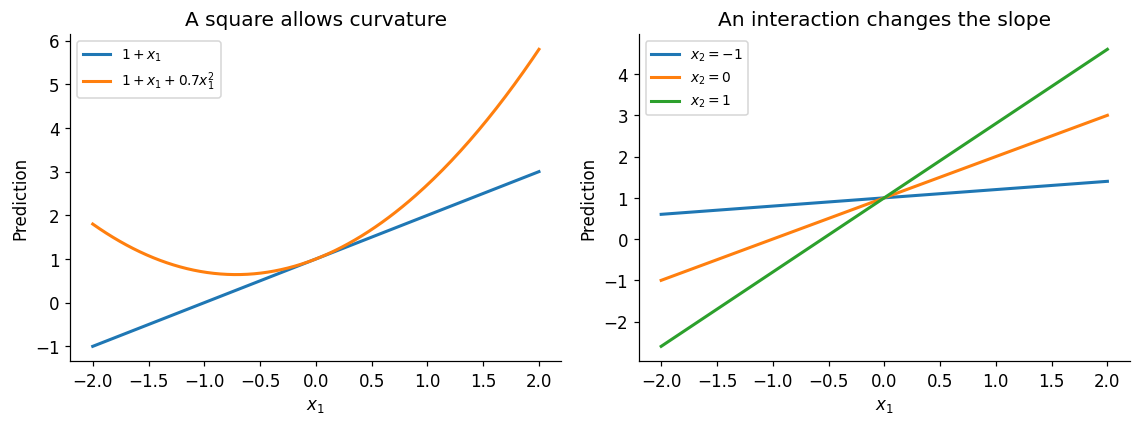

In [17]:
# Illustrations of the equations, not measured battery data.
x = np.linspace(-2, 2, 200)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
axes[0].plot(x, 1 + x, label=r"$1+x_1$", linewidth=2)
axes[0].plot(x, 1 + x + 0.7 * x ** 2, label=r"$1+x_1+0.7x_1^2$", linewidth=2)
axes[0].set(xlabel=r"$x_1$", ylabel="Prediction", title="A square allows curvature")
for x2 in [-1, 0, 1]:
    axes[1].plot(x, 1 + x + 0.8 * x * x2, linewidth=2, label=rf"$x_2={x2}$")
axes[1].set(xlabel=r"$x_1$", ylabel="Prediction", title="An interaction changes the slope")
for ax in axes:
    ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### Physical ratios

The maximum curve capacity at cycle 2 gives an initial reference level. Dividing by it
expresses capacity changes relative to that level.

```latex
r_{\Delta}=\frac{M_{100}-M_2}{M_2},\qquad r_s=\frac{s_M}{M_2}
```

The first ratio is the net fractional change from cycle 2 to cycle 100. Multiplying by 100
gives a percentage. The second is the slope of the linear capacity trend over cycles 2-100,
divided by the cycle-2 capacity. Its units are per cycle. A negative slope describes a
declining trend over that interval, not a constant degradation rate throughout the battery's life.

The following figure uses battery `b2c29`, the same training example as Lecture 09.

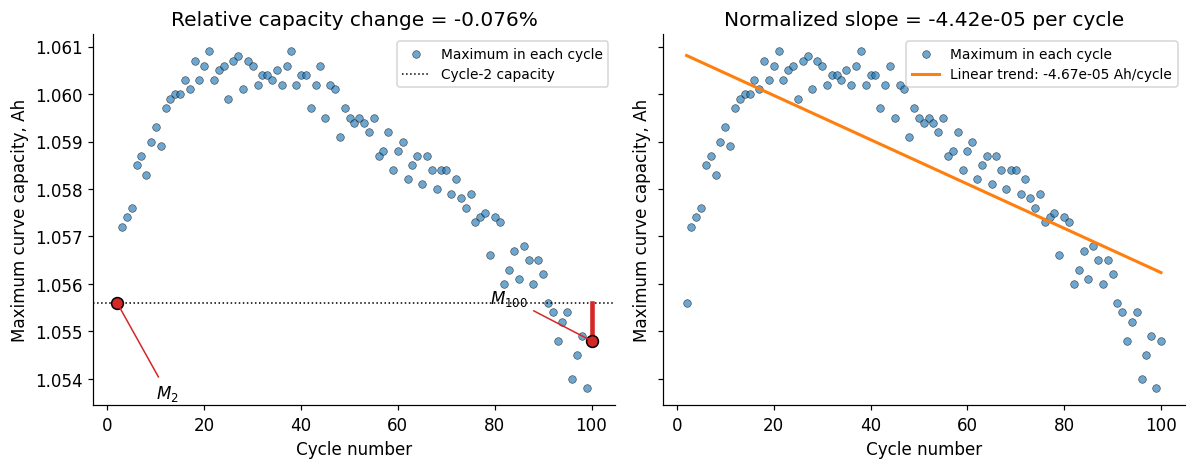

In [18]:
Q = np.loadtxt(DATA_DIR / "discharge_curves_b2c29.csv", delimiter=",")
cycles = np.arange(2, 101)
max_capacity = Q.max(axis=0)
M2, M100 = max_capacity[[0, -1]]
slope, intercept = np.polyfit(cycles, max_capacity, 1)
r_delta = (M100 - M2) / M2
r_s = slope / M2

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax in axes:
    ax.scatter(cycles, max_capacity, s=25, alpha=0.65, edgecolor="black", linewidth=0.4,
               label="Maximum in each cycle")
    ax.set(xlabel="Cycle number", ylabel="Maximum curve capacity, Ah")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes[0].axhline(M2, color="black", linestyle=":", linewidth=1, label="Cycle-2 capacity")
axes[0].scatter([2, 100], [M2, M100], s=60, color="C3", edgecolor="black", zorder=3)
axes[0].plot([100, 100], [M2, M100], color="C3", linewidth=3)
axes[0].annotate(r"$M_2$", xy=(2, M2), xytext=(10, M2 - 0.002),
                 arrowprops={"arrowstyle": "-", "color": "C3"})
axes[0].annotate(r"$M_{100}$", xy=(100, M100), xytext=(79, M100 + 0.0008),
                 arrowprops={"arrowstyle": "-", "color": "C3"})
axes[0].set_title(f"Relative capacity change = {100 * r_delta:.3f}%")
axes[1].plot(cycles, intercept + slope * cycles, color="C1", linewidth=2,
             label=f"Linear trend: {slope:.2e} Ah/cycle")
axes[1].set_title(f"Normalized slope = {r_s:.2e} per cycle")
for ax in axes:
    ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

In [19]:
def add_physical_ratios(X):
    # Column 3 is M2, column 4 is M100 - M2, and column 5 is the slope.
    X = np.asarray(X, dtype=float)
    M2 = X[:, 3]
    if np.any(M2 <= 0):
        raise ValueError("The cycle-2 capacity must be positive.")
    return np.column_stack([X, X[:, 4] / M2, X[:, 5] / M2])


ratio_transformer = FunctionTransformer(add_physical_ratios, validate=False)
X_train_ratios = ratio_transformer.fit_transform(X_train)
print("Stored input columns:", X_train.shape)
print("With physical ratios:", X_train_ratios.shape)

Stored input columns: (41, 6)
With physical ratios: (41, 8)


## 6. Comparing feature engineering methods

Now we hold preprocessing fixed:

- Yeo-Johnson for every input column;
- log10 for the target;
- the same fixed training and validation groups.

Only the feature representation and the retuned alpha change within each model.
This makes the effect of feature engineering easier to interpret.

In [20]:
feature_steps = {
    "None": "passthrough",
    "Physical ratios": ratio_transformer,
    "Polynomial features": PolynomialFeatures(2, include_bias=False),
    "Interaction features": PolynomialFeatures(
        2, interaction_only=True, include_bias=False,
    ),
}

# Confirm the number of columns created from the six stored features.
for name, step in feature_steps.items():
    transformed = X_train if isinstance(step, str) else step.fit_transform(X_train)
    print(f"{name:20s}: {transformed.shape[1]} columns")

None                : 6 columns
Physical ratios     : 8 columns
Polynomial features : 27 columns
Interaction features: 21 columns


In [21]:
# Tune Ridge and Lasso separately for each feature representation.
feature_searches = {"Ridge": {}, "Lasso": {}}
for model_name, model in model_choices.items():
    alphas = ridge_alphas if model_name == "Ridge" else lasso_log_alphas
    for feature_name, feature_step in feature_steps.items():
        search = tune_regression(
            feature_step,
            PowerTransformer(method="yeo-johnson", standardize=True),
            target_preprocessors["Log10"],
            clone(model), alphas, fixed_split,
        )
        feature_searches[model_name][feature_name] = search

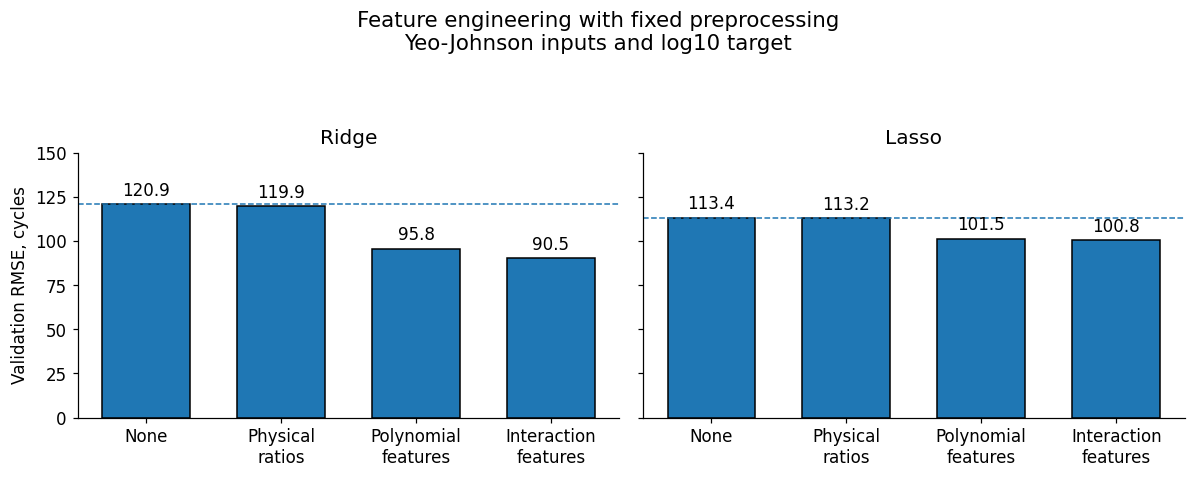

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
short_names = ["None", "Physical\nratios", "Polynomial\nfeatures", "Interaction\nfeatures"]

for ax, (model_name, searches) in zip(axes, feature_searches.items()):
    values = [-search.best_score_ for search in searches.values()]
    bars = ax.bar(np.arange(4), values, color="C0", edgecolor="black", width=0.65)
    ax.bar_label(bars, fmt="%.1f", padding=3)
    ax.axhline(values[0], color="C0", linestyle="--", linewidth=1)
    ax.set_xticks(np.arange(4), labels=short_names)
    ax.set_title(model_name)
    ax.set_ylim(0, 150)

axes[0].set_ylabel("Validation RMSE, cycles")
fig.suptitle("Feature engineering with fixed preprocessing\n"
             "Yeo-Johnson inputs and log10 target", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

The dashed line is the model with no feature engineering. Comparing each bar with that
line shows the change associated with adding features under the same preprocessing.

## 7. A separate five-fold comparison

The fixed-split experiment reproduces the 41/43/40 classroom setup. Five-fold CV asks a
different question: does the result remain stable when the 84 development batteries take
turns serving as validation data?

The same five folds are used for every representation. The 40 test batteries remain separate.

In [23]:
# Build the folds once so all methods use the same validation batteries.
kfold = KFold(n_splits=5, shuffle=True, random_state=26)
folds = list(kfold.split(X_dev))
cv_searches = {"Ridge": {}, "Lasso": {}}

for model_name, model in model_choices.items():
    alphas = ridge_alphas if model_name == "Ridge" else lasso_log_alphas
    for feature_name, feature_step in feature_steps.items():
        search = tune_regression(
            feature_step,
            PowerTransformer(method="yeo-johnson", standardize=True),
            target_preprocessors["Log10"],
            clone(model), alphas, folds,
        )
        cv_searches[model_name][feature_name] = search

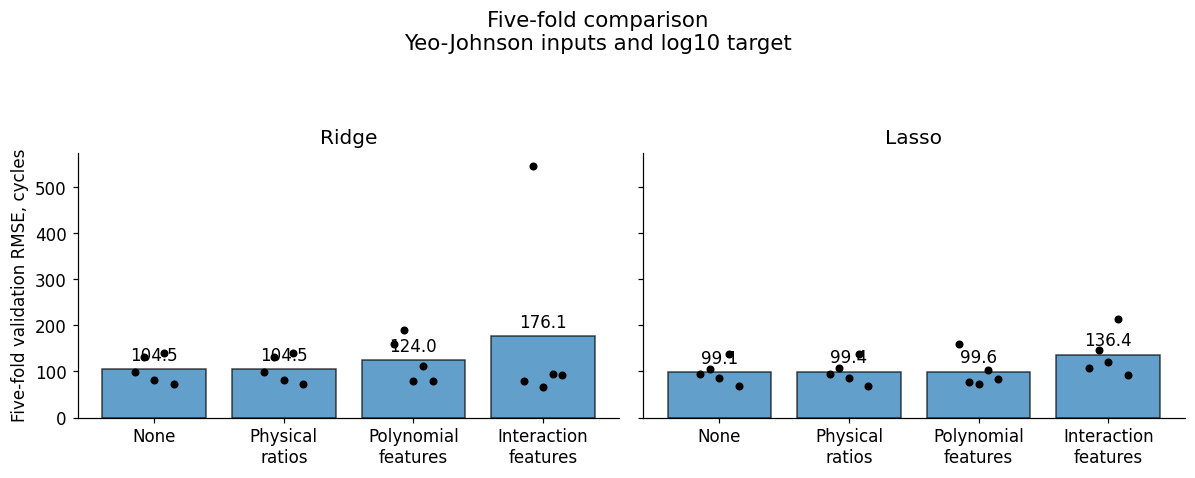

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, (model_name, searches) in zip(axes, cv_searches.items()):
    means = []
    for position, search in enumerate(searches.values()):
        best = search.best_index_
        scores = -np.array([
            search.cv_results_[f"split{k}_test_score"][best] for k in range(5)
        ])
        means.append(scores.mean())
        ax.scatter(position + np.linspace(-0.15, 0.15, 5), scores,
                   color="black", s=18, zorder=3)

    bars = ax.bar(np.arange(4), means, color="C0", edgecolor="black", alpha=0.7)
    ax.bar_label(bars, fmt="%.1f", padding=3)
    ax.set_xticks(np.arange(4), labels=short_names)
    ax.set_title(model_name)

axes[0].set_ylabel("Five-fold validation RMSE, cycles")
fig.suptitle("Five-fold comparison\nYeo-Johnson inputs and log10 target", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

### Elastic Net extension

Elastic Net combines L1 and L2 penalties. This optional example uses physical ratios,
Yeo-Johnson input preprocessing, a log10 target, and the same five folds.

In [25]:
elastic_pipeline = Pipeline([
    ("features", ratio_transformer),
    ("preprocess", PowerTransformer(method="yeo-johnson")),
    ("model", ElasticNet(max_iter=100000, tol=1e-6)),
])
elastic_model = TransformedTargetRegressor(
    regressor=elastic_pipeline,
    transformer=target_preprocessors["Log10"],
)
elastic_search = GridSearchCV(
    elastic_model,
    {
        "regressor__model__alpha": np.logspace(-4, 1, 21),
        "regressor__model__l1_ratio": [0.1, 0.5, 0.9, 1.0],
    },
    scoring="neg_root_mean_squared_error",
    cv=folds,
    refit=True,
    error_score="raise",
).fit(X_dev, y_dev)

print("Best alpha:", elastic_search.best_params_["regressor__model__alpha"])
print("Best l1_ratio:", elastic_search.best_params_["regressor__model__l1_ratio"])
print(f"Mean validation RMSE: {-elastic_search.best_score_:.2f} cycles")

Best alpha: 0.00031622776601683794
Best l1_ratio: 1.0
Mean validation RMSE: 97.43 cycles


## 8. Evaluating the selected models

All preprocessing choices, feature representations, and alpha values are now selected.
We can finally evaluate predictions on the 40 test batteries. Every reported RMSE is in cycles.
The test bars describe final performance; they must not be used to choose another pipeline.

In [26]:
X_test, y_test = X[test_mask], y[test_mask]


def evaluate(search):
    # Return validation RMSE, test RMSE, and test predictions.
    prediction = search.predict(X_test)
    return {
        "validation": -search.best_score_,
        "test": root_mean_squared_error(y_test, prediction),
        "prediction": prediction,
        "alpha": search.best_params_["regressor__model__alpha"],
    }


scaling_results = {key: evaluate(search) for key, search in scaling_searches.items()}
feature_results = {
    model_name: {name: evaluate(search) for name, search in searches.items()}
    for model_name, searches in feature_searches.items()
}
baseline = scaling_results[("StandardScaler", "Raw")]
print(f"Baseline: validation {baseline['validation']:.2f}, test {baseline['test']:.2f} cycles")

Baseline: validation 148.90, test 193.28 cycles


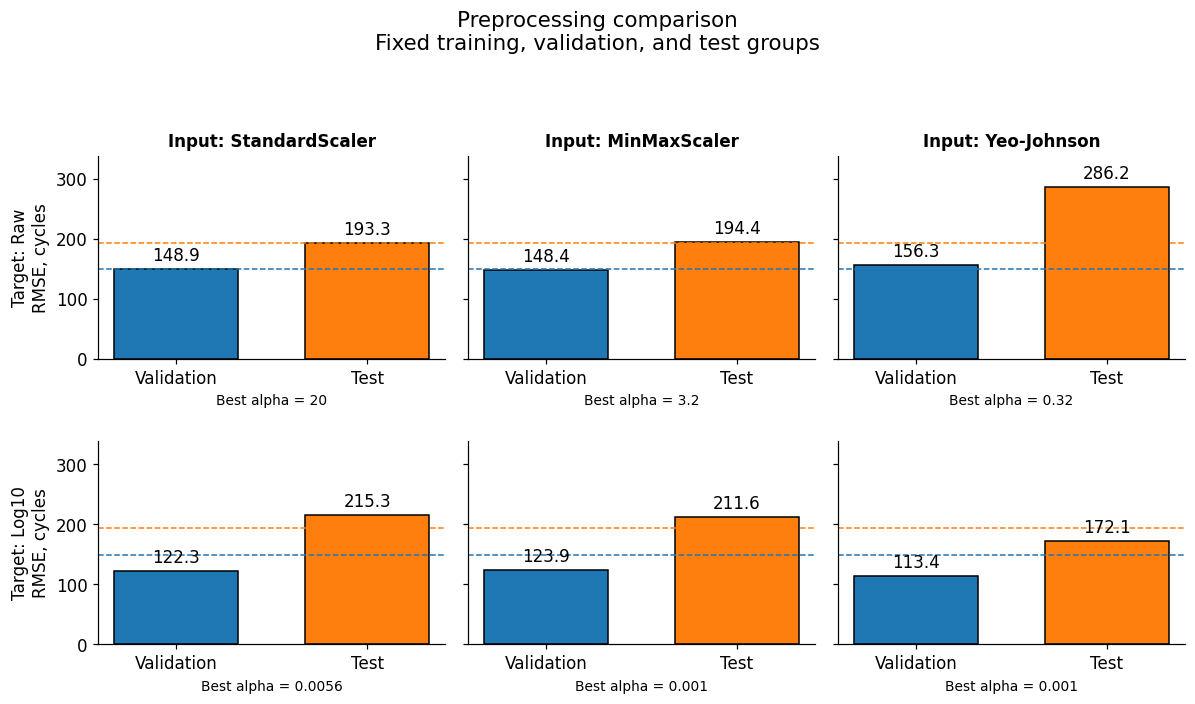

In [27]:
def plot_error_bars(ax, result, ymax, reference=None):
    bars = ax.bar(
        ["Validation", "Test"],
        [result["validation"], result["test"]],
        color=["C0", "C1"], edgecolor="black", width=0.65,
    )
    ax.bar_label(bars, fmt="%.1f", padding=3)
    if reference is not None:
        ax.axhline(reference["validation"], color="C0", linestyle="--", linewidth=1)
        ax.axhline(reference["test"], color="C1", linestyle="--", linewidth=1)
    ax.set_ylim(0, ymax)
    ax.set_xlabel(f"Best alpha = {result['alpha']:.2g}", fontsize=9)


fig, axes = plt.subplots(2, 3, figsize=(11, 6.5), sharey=True)
ymax = 1.18 * max(max(r["validation"], r["test"]) for r in scaling_results.values())
for row, target_name in enumerate(target_preprocessors):
    for column, input_name in enumerate(input_preprocessors):
        ax = axes[row, column]
        result = scaling_results[(input_name, target_name)]
        plot_error_bars(ax, result, ymax, baseline)
        if row == 0:
            ax.set_title(f"Input: {input_name}", fontsize=11, fontweight="bold")
        if column == 0:
            ax.set_ylabel(f"Target: {target_name}\nRMSE, cycles")

fig.suptitle("Preprocessing comparison\nFixed training, validation, and test groups", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.92], h_pad=2)
plt.show()

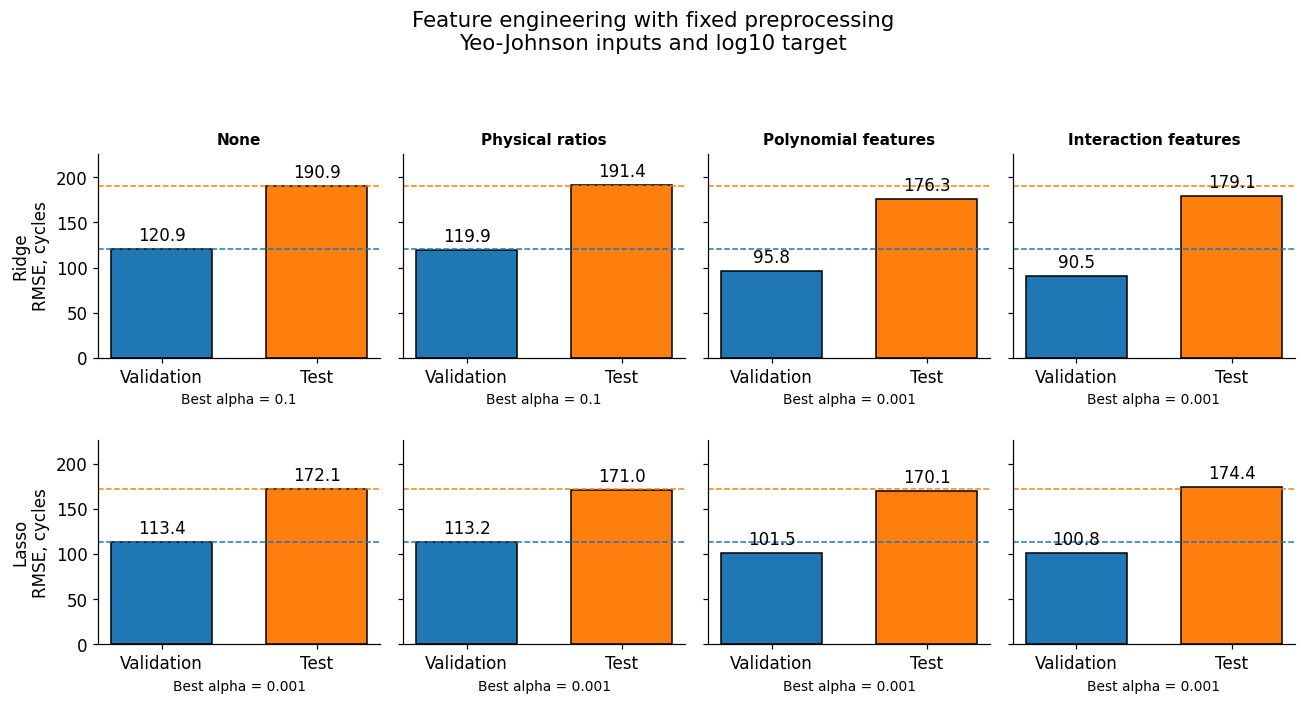

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6.5), sharey=True)
ymax = 1.18 * max(
    max(result["validation"], result["test"])
    for model_results in feature_results.values()
    for result in model_results.values()
)

for row, (model_name, model_results) in enumerate(feature_results.items()):
    reference = model_results["None"]
    for column, (feature_name, result) in enumerate(model_results.items()):
        ax = axes[row, column]
        plot_error_bars(ax, result, ymax, reference)
        if row == 0:
            ax.set_title(feature_name, fontsize=10, fontweight="bold")
        if column == 0:
            ax.set_ylabel(f"{model_name}\nRMSE, cycles")

fig.suptitle("Feature engineering with fixed preprocessing\n"
             "Yeo-Johnson inputs and log10 target", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.92], h_pad=2)
plt.show()

In [29]:
for model_name, model_results in feature_results.items():
    reference = model_results["None"]
    print(model_name)
    for feature_name, result in model_results.items():
        validation_change = 100 * (1 - result["validation"] / reference["validation"])
        test_change = 100 * (1 - result["test"] / reference["test"])
        print(f"  {feature_name:20s} validation {result['validation']:6.2f}, "
              f"test {result['test']:6.2f}, changes {validation_change:5.1f}% "
              f"and {test_change:5.1f}%")

Ridge
  None                 validation 120.90, test 190.87, changes   0.0% and   0.0%
  Physical ratios      validation 119.86, test 191.40, changes   0.9% and  -0.3%
  Polynomial features  validation  95.77, test 176.32, changes  20.8% and   7.6%
  Interaction features validation  90.54, test 179.11, changes  25.1% and   6.2%
Lasso
  None                 validation 113.40, test 172.06, changes   0.0% and   0.0%
  Physical ratios      validation 113.15, test 171.05, changes   0.2% and   0.6%
  Polynomial features  validation 101.54, test 170.11, changes  10.5% and   1.1%
  Interaction features validation 100.76, test 174.36, changes  11.1% and  -1.3%


The comparison above answers a narrow question: what changes when we add engineered
features while keeping the input and target preprocessing fixed?

For Lasso, most of the improvement over the starting baseline comes from Yeo-Johnson
input preprocessing and the log10 target. Physical ratios add a smaller improvement.
For Ridge, polynomial features produce a clearer additional improvement.

### Prediction plots

The diagonal represents perfect predictions. The four panels show the progression from
the starting baseline to preprocessing and then feature engineering.

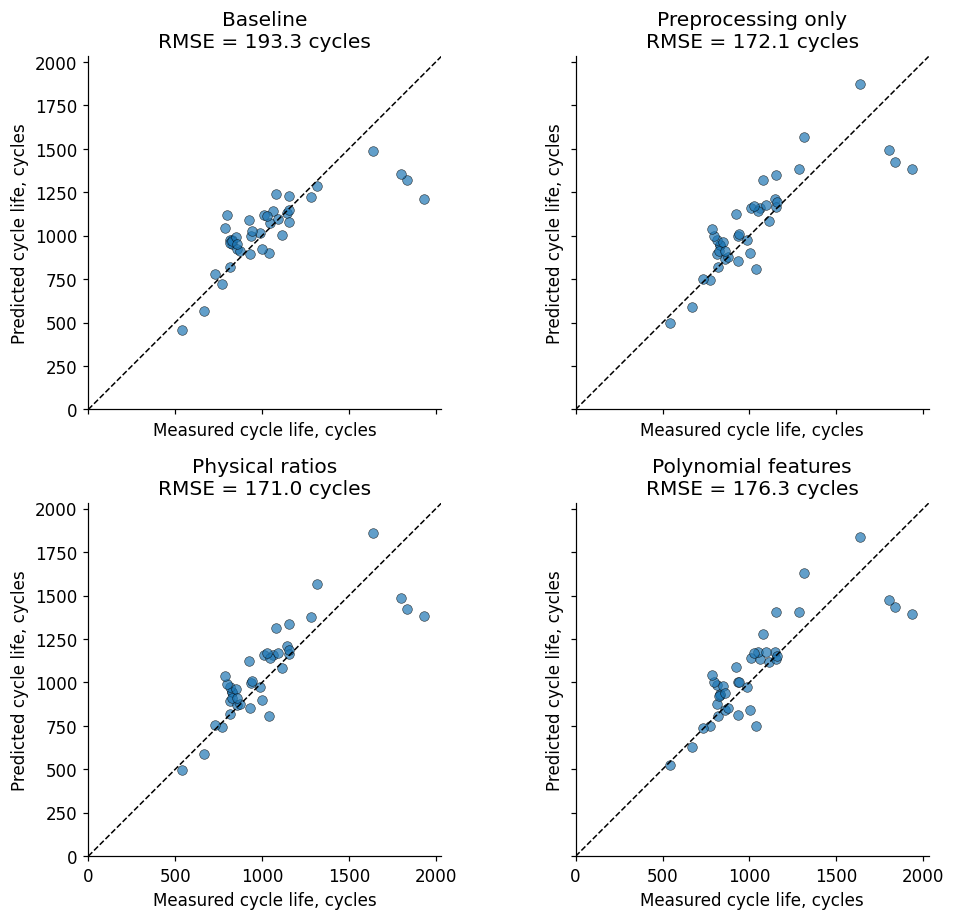

In [30]:
parity_results = {
    "Baseline": baseline,
    "Preprocessing only": scaling_results[("Yeo-Johnson", "Log10")],
    "Physical ratios": feature_results["Lasso"]["Physical ratios"],
    "Polynomial features": feature_results["Ridge"]["Polynomial features"],
}
upper = 1.05 * max(
    y_test.max(),
    max(result["prediction"].max() for result in parity_results.values()),
)

fig, axes = plt.subplots(2, 2, figsize=(9.5, 8.5), sharex=True, sharey=True)
for ax, (name, result) in zip(axes.flat, parity_results.items()):
    prediction = result["prediction"]
    ax.scatter(y_test, prediction, s=40, alpha=0.7,
               edgecolor="black", linewidth=0.4)
    ax.plot([0, upper], [0, upper], "k--", linewidth=1)
    ax.set(
        title=f"{name}\nRMSE = {result['test']:.1f} cycles",
        xlim=(0, upper), ylim=(0, upper), aspect="equal",
        xlabel="Measured cycle life, cycles",
        ylabel="Predicted cycle life, cycles",
    )

fig.tight_layout()
plt.show()

### Five-fold selections

For each model, choose the feature representation with the lowest mean five-fold RMSE.
Then evaluate that selected model on the same 40 test batteries.

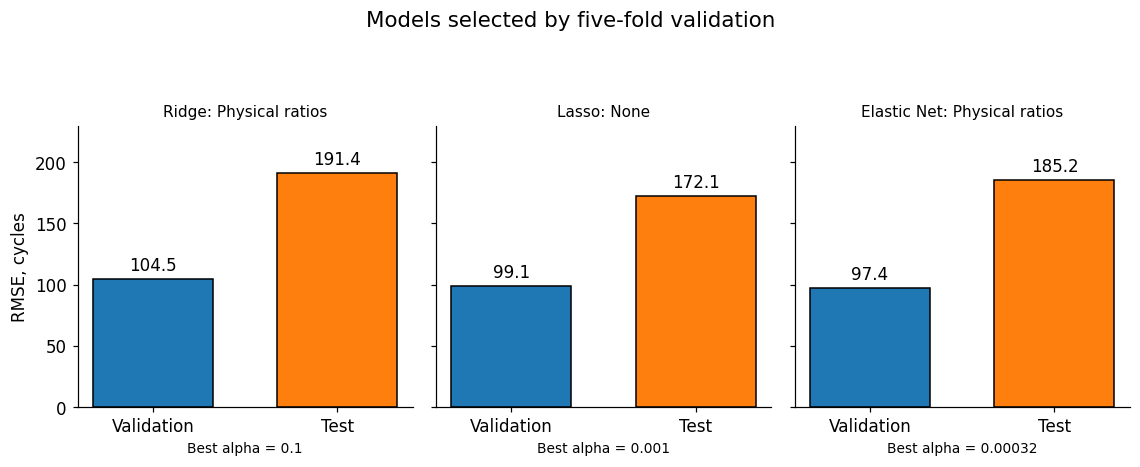

In [31]:
cv_results = {}
for model_name, searches in cv_searches.items():
    selected_name = min(searches, key=lambda name: -searches[name].best_score_)
    result = evaluate(searches[selected_name])
    cv_results[model_name] = (selected_name, result)

elastic_result = evaluate(elastic_search)
fig, axes = plt.subplots(1, 3, figsize=(10.5, 4.3), sharey=True)
rows = [
    ("Ridge", *cv_results["Ridge"]),
    ("Lasso", *cv_results["Lasso"]),
    ("Elastic Net", "Physical ratios", elastic_result),
]
ymax = 1.2 * max(max(result["validation"], result["test"])
                 for _, _, result in rows)

for ax, (model_name, feature_name, result) in zip(axes, rows):
    plot_error_bars(ax, result, ymax)
    ax.set_title(f"{model_name}: {feature_name}", fontsize=10)

axes[0].set_ylabel("RMSE, cycles")
fig.suptitle("Models selected by five-fold validation", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()